<a href="https://colab.research.google.com/github/ariafcode/dsrp/blob/main/dsrp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import pandas as pd
df=pd.read_csv('/content/NCD_RisC_Nature_2020_Cholesterol_age_standardised_countries.csv')
df.head()

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Mean total cholesterol lower 95% uncertainty interval (mmol/L),Mean total cholesterol upper 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),Mean HDL cholesterol (mmol/L),Mean HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)
0,Afghanistan,AFG,Men,1980,4.263545,3.539636,4.959936,2.919134,2.486837,3.339214,1.221839,0.926460,1.497237
1,Afghanistan,AFG,Men,1981,4.266327,3.569655,4.931141,2.934723,2.512884,3.344176,1.214738,0.932500,1.476955
2,Afghanistan,AFG,Men,1982,4.269252,3.612601,4.904159,2.950451,2.543536,3.345615,1.207716,0.935305,1.462378
3,Afghanistan,AFG,Men,1983,4.272437,3.646602,4.881011,2.966397,2.570361,3.353339,1.200752,0.943039,1.444552
4,Afghanistan,AFG,Men,1984,4.275822,3.673783,4.866126,2.982507,2.598309,3.360546,1.193839,0.947619,1.427836


In [33]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.lower()
df_clean.columns = df_clean.columns.str.replace(" ", "_")
df_clean.columns = df_clean.columns.str.replace("(", "").str.replace(")", "").str.replace("/", "_")

#df = df.rename(columns={'Mean total cholesterol (mmol/L)': 'Mean Total Cholesterol (mmol/L)'})
#df = df.rename(columns={'Mean total cholesterol lower 95% uncertainty interval (mmol/L)':'Mean Total Cholesterol Lower 95% Uncertainty Interval (mmol/L)'})
#df = df.rename(columns={'Mean total cholesterol upper 95% uncertainty interval (mmol/L)':'Mean Total Cholesterol Upper 95% Uncertainty Interval (mmol/L)'})
#df = df.rename(columns={'Mean non-HDL cholesterol (mmol/L)':'Mean Non-HDL Cholesterol (mmol/L)'})
#df = df.rename(columns={'Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L)':'Mean Non-HDL Cholesterol Lower 95% Uncertainty Interval (mmol/L)'})
#df = df.rename(columns={'Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L)':'Mean Non-HDL Cholesterol Upper 95% Uncertainty Interval (mmol/L)'})
#df = df.rename(columns={'Mean HDL cholesterol (mmol/L)':'Mean HDL Cholesterol (mmol/L)'})
#df = df.rename(columns={'Mean HDL cholesterol lower 95% uncertainty interval (mmol/L)':'Mean Cholesterol Lower 95% Uncertainty Interval (mmol/L)'})
#df = df.rename(columns={'Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)':'Mean HDL Cholesterol Upper 95% Uncertainty Interval (mmol/L)'})
df_clean.head()


,country_region_world,iso,sex,year,mean_total_cholesterol_mmol_l,mean_total_cholesterol_lower_95%_uncertainty_interval_mmol_l,mean_total_cholesterol_upper_95%_uncertainty_interval_mmol_l,mean_non-hdl_cholesterol_mmol_l,mean_non-hdl_cholesterol_lower_95%_uncertainty_interval_mmol_l,mean_non-hdl_cholesterol_upper_95%_uncertainty_interval_mmol_l,mean_hdl_cholesterol_mmol_l,mean_cholesterol_lower_95%_uncertainty_interval_mmol_l,mean_hdl_cholesterol_upper_95%_uncertainty_interval_mmol_l
0,Afghanistan,AFG,Men,1980,4.263545,3.539636,4.959936,2.919134,2.486837,3.339214,1.221839,0.926460,1.497237
1,Afghanistan,AFG,Men,1981,4.266327,3.569655,4.931141,2.934723,2.512884,3.344176,1.214738,0.932500,1.476955
2,Afghanistan,AFG,Men,1982,4.269252,3.612601,4.904159,2.950451,2.543536,3.345615,1.207716,0.935305,1.462378
3,Afghanistan,AFG,Men,1983,4.272437,3.646602,4.881011,2.966397,2.570361,3.353339,1.200752,0.943039,1.444552
4,Afghanistan,AFG,Men,1984,4.275822,3.673783,4.866126,2.982507,2.598309,3.360546,1.193839,0.947619,1.427836


In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 13 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   country_region_world                                            15600 non-null  object 
 1   iso                                                             15600 non-null  object 
 2   sex                                                             15600 non-null  object 
 3   year                                                            15600 non-null  int64  
 4   mean_total_cholesterol_mmol_l                                   15600 non-null  float64
 5   mean_total_cholesterol_lower_95%_uncertainty_interval_mmol_l    15600 non-null  float64
 6   mean_total_cholesterol_upper_95%_uncertainty_interval_mmol_l    15600 non-null  float64
 7   mean_non-hdl_cholesterol_mmol_l                  

In [36]:
df_clean.isna().sum()

,0
country_region_world,0
iso,0
sex,0
year,0
mean_total_cholesterol_mmol_l,0
mean_total_cholesterol_lower_95%_uncertainty_interval_mmol_l,0
mean_total_cholesterol_upper_95%_uncertainty_interval_mmol_l,0
mean_non-hdl_cholesterol_mmol_l,0
mean_non-hdl_cholesterol_lower_95%_uncertainty_interval_mmol_l,0
mean_non-hdl_cholesterol_upper_95%_uncertainty_interval_mmol_l,0


In [37]:
df_clean.duplicated().sum()

np.int64(0)

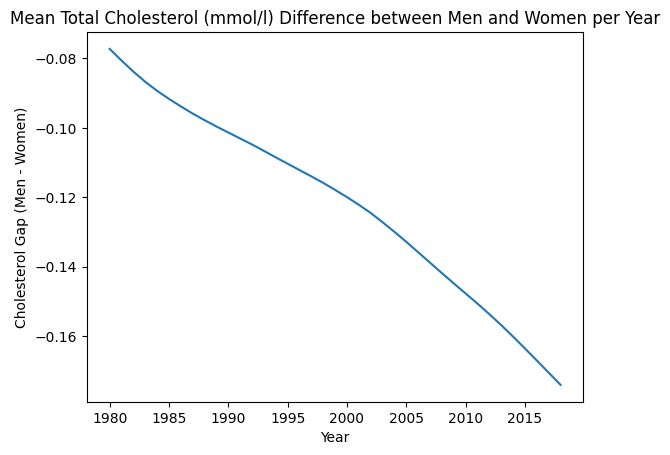

In [62]:
#How has the gap between men's and women's age-standardized cholesterol levels evolved globally from 1980 to 2020?
import matplotlib.pyplot as plt

df_men = df_clean[df_clean['sex'] == 'Men']
df_women = df_clean[df_clean['sex']== 'Women']

men_yearly_mean = df_men.groupby("year")['mean_total_cholesterol_mmol_l'].mean()
women_yearly_mean = df_women.groupby("year")['mean_total_cholesterol_mmol_l'].mean()

cholesterol_gap = men_yearly_mean - women_yearly_mean.values

plt.plot(cholesterol_gap.index, cholesterol_gap.values)
plt.xlabel('Year')
plt.ylabel('Cholesterol Gap (Men - Women)')
plt.title('Mean Total Cholesterol (mmol/l) Difference between Men and Women per Year')
plt.show()


In [67]:
#Which countries have experienced the largest drop in total cholesterol since 1980 and which have seen the largest spike?
df_firstyear = df_clean[df_clean['year'] == 1980]
df_lastyear = df_clean[df_clean['year'] == 2018]

chol_1980 = df_firstyear.groupby('country_region_world')['mean_total_cholesterol_mmol_l'].mean()
chol_2018 = df_lastyear.groupby('country_region_world')['mean_total_cholesterol_mmol_l'].mean()
chol_change = chol_2018 - chol_1980

sorted_changes = chol_change.sort_values(ascending=False)

print("Top 5 Largest Spikes in Cholesterol:")
print(sorted_changes.head(5))

print('Top 5 Largest Drops in Cholesterol')
print(sorted_changes.tail(5))




Top 5 Largest Spikes in Cholesterol:
country_region_world
Indonesia    0.534533
Thailand     0.488129
China        0.483944
Malaysia     0.471072
Maldives     0.436020
Name: mean_total_cholesterol_mmol_l, dtype: float64
Top 5 Largest Drops in Cholesterol
country_region_world
Switzerland   -1.212542
Finland       -1.219858
Sweden        -1.221313
Iceland       -1.321437
Belgium       -1.454066
Name: mean_total_cholesterol_mmol_l, dtype: float64


In [71]:
#How has the ratio of non-HDL to HDL cholesterol shifted over the past four decades and which regions have seen the steepest increases?
df_clean['ratio_of_non-HDL_to_HDL'] = df_clean['mean_non-hdl_cholesterol_mmol_l']/df_clean['mean_hdl_cholesterol_mmol_l']
df_1980 = df_clean[df_clean['year'] == 1980]
df_2018 = df_clean[df_clean['year'] == 2018]

ratio_1980 = df_1980.groupby('country_region_world')['ratio_of_non-HDL_to_HDL'].mean()
ratio_2018 = df_2018.groupby('country_region_world')['ratio_of_non-HDL_to_HDL'].mean()

percentage_change = ((ratio_2018 - ratio_1980) /ratio_1980)*100

sharpest_spikes = percentage_change.sort_values(ascending=False)
print('Top 5 Sharpest Upward Spikes in Cholesterol Ratio (Non-HDL to HDL) (1980 vs 2018)')
print(sharpest_spikes.head(5))

Top 5 Sharpest Upward Spikes in Cholesterol Ratio (Non-HDL to HDL) (1980 vs 2018)
country_region_world
Tokelau            61.680921
Malawi             47.179736
Burundi            47.036975
Solomon Islands    46.192135
Cambodia           42.905607
Name: ratio_of_non-HDL_to_HDL, dtype: float64
